Download ISIC 2024

In [ ]:
import kagglehub
import os
# You may need to re-run this cell after logging in.
kagglehub.login()
path_isic_2024 = kagglehub.competition_download('isic-2024-challenge')

100%|██████████| 2.00G/2.00G [00:18<00:00, 116MB/s]

Extracting files...


In [ ]:
import pandas as pd

df = pd.read_csv(path_isic_2024 + '/train-metadata.csv')

df.head()

/tmp/ipykernel_14570/2526766579.py:3: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_isic_2024 + '/train-metadata.csv')


,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [ ]:
# keep necessary columns and add a dataset identifer for each image
columns = ['isic_id','target','patient_id']
df_isic_2024 = df[columns].copy()
df_isic_2024['source'] = 'isic_2024'

Number of targets for each class {Malignant: 0,Benign: 1}

In [ ]:
df_isic_2024['target'].value_counts()

,count
target,
0,400666
1,393


In [ ]:
print("Number of patients is: ",df_isic_2024['patient_id'].nunique())

Number of patients is:  1042


In [ ]:
print("Number of distinct patients with malignant lesion:",df_isic_2024[df_isic_2024['target'] == 1]['patient_id'].nunique())

Number of distinct patients with malignant lesion: 259


Download ISIC 2020

In [ ]:
# Download latest version
path_isic_2020 = kagglehub.dataset_download("nischaydnk/isic-2020-jpg-256x256-resized")

print("Path to dataset files:", path_isic_2020)

100%|██████████| 595M/595M [00:04<00:00, 136MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nischaydnk/isic-2020-jpg-256x256-resized/versions/1


In [ ]:

df_isic_2020 = pd.read_csv(path_isic_2020 + '/train-metadata.csv')
df_isic_2020['source'] = 'isic_2020' # add dataset identifier to this dataset as well

df_isic_2020.head()

,Unnamed: 0,isic_id,patient_id,target,source
0,0,ISIC_2637011,IP_7279968,0,isic_2020
1,1,ISIC_0015719,IP_3075186,0,isic_2020
2,2,ISIC_0052212,IP_2842074,0,isic_2020
3,3,ISIC_0068279,IP_6890425,0,isic_2020
4,4,ISIC_0074268,IP_8723313,0,isic_2020


In [ ]:
print("Number of unique patients is: ", df_isic_2020['patient_id'].nunique())

Number of unique patients is:  2056


In [ ]:
df_isic_2020["target"].value_counts()

,count
target,
0,32542
1,584


In [ ]:
print("Number of distict patients with malignant lesion:",df_isic_2020[df_isic_2020['target'] == 1]['patient_id'].nunique())

Number of distict patients with malignant lesion: 428


In [ ]:

common_patient_ids = df_isic_2020[df_isic_2020['patient_id'].isin(df_isic_2024['patient_id'])]['patient_id'].nunique()
print(f"Number of common patient IDs between ISIC 2020 and ISIC 2024: {common_patient_ids}")

Number of common patient IDs between ISIC 2020 and ISIC 2024: 76


combine ISIC 2020 and ISIC 2024

In [ ]:
df_combined = pd.concat([df_isic_2020, df_isic_2024], ignore_index=True)

In [ ]:
df_combined = df_combined.drop(columns=['Unnamed: 0'])

In [ ]:
df_combined['target'].value_counts()

,count
target,
0,433208
1,977


In [ ]:
# how many unique malignant patients?
print(f"Distinct number of patients with malignant lesion", df_combined[df_combined['target'] == 1]['patient_id'].nunique())


Distinct number of patients with malignant lesion 675


Display distribution of both datasets

In [ ]:
isic_2020_malignant = df_isic_2020['target'].value_counts()
isic_2024_malignant = df_isic_2024['target'].value_counts()
isic_2020_benign = df_isic_2020['target'].value_counts()
isic_2024_benign = df_isic_2024['target'].value_counts()

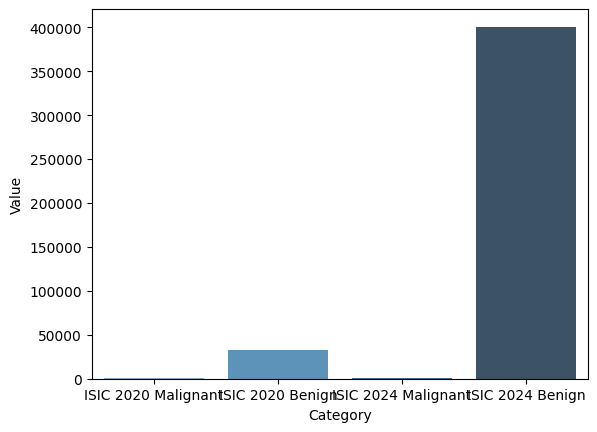

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt # Added to ensure plt.show() works

datset_distribution_df = pd.DataFrame({'Category': ['ISIC 2020 Malignant', 'ISIC 2020 Benign', 'ISIC 2024 Malignant', 'ISIC 2024 Benign'], 'Value': [isic_2020_malignant[1], isic_2020_benign[0], isic_2024_malignant[1], isic_2024_benign[0]]})

sns.barplot(data=datset_distribution_df, x='Category', y='Value', hue='Category', palette='Blues_d', legend=False)
plt.show()

patient id aware data splitting to prevent data leakage, ie. preventing the same patient from appearing in train, test, and validation data

In [ ]:
# split dataset by malignant and benign

benign_df = df_combined[df_combined['target'] == 0]
malignant_df = df_combined[df_combined['target'] == 1]



In [ ]:
# create function to retrieve train, validation, and test data
from sklearn.model_selection import GroupShuffleSplit

def split_data(data, random_state=42):
  splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=random_state)
  # returns the 90% train and 10% test data
  train_val_idx, test_idx = next(splitter_test.split(data, groups=data['patient_id'])) # ensuring patient id is considered when splitting

  splitter_val = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=random_state)
  # returns the 80% train and 10% val data
  train_idx, val_idx = next(splitter_val.split(data.iloc[train_val_idx], groups=data.iloc[train_val_idx]['patient_id']))

  # 80% train
  train_df = data.iloc[train_idx]
  # 10% validation
  val_df = data.iloc[val_idx]
  # 10% test
  test_df = data.iloc[test_idx]

  return train_df, val_df, test_df



In [ ]:
# sample 2000 images from benign dataset about 1000 from malignant

benign_df_sample = benign_df.sample(n=2000, random_state=42)

benign_train, benign_val, benign_test = split_data(benign_df_sample)
malignant_train, malignant_val, malignant_test = split_data(malignant_df)

total_benign= len(benign_train) + len(benign_val) + len(benign_test)
total_malignant = len(malignant_train) + len(malignant_val) + len(malignant_test)

print(f"Total benign images: {total_benign}")
print(f"Total malignant images: {total_malignant}")


Total benign images: 2000
Total malignant images: 977


In [ ]:
train_df = pd.concat([benign_train, malignant_train], ignore_index=True)
val_df = pd.concat([benign_val, malignant_val], ignore_index=True)
test_df = pd.concat([benign_test, malignant_test], ignore_index=True)

In [ ]:
train_df['target'].value_counts()

,count
target,
0,1642
1,765


In [ ]:
val_df['target'].value_counts()

,count
target,
0,169
1,90


In [ ]:
test_df['target'].value_counts()

,count
target,
0,189
1,122


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class ISIC_Dataset(Dataset):
    def __init__(self, df: pd.DataFrame,dataset_paths:dict,transforms=None):
        self.df = df
        self.transforms = transforms
        self.dataset_paths = dataset_paths

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # choose what dataset to find image from
        if row['source'] == 'isic_2020':
            img_path = os.path.join(self.dataset_paths['isic-2020'], 'train-image/image', row['isic_id'] + '.jpg')
        elif row['source'] == 'isic_2024':
            img_path = os.path.join(self.dataset_paths['isic-2024'], 'train-image/image', row['isic_id'] + '.jpg')
        # open image
        image = Image.open(img_path).convert('RGB')
        if self.transforms:
            image = self.transforms(image)
        label = torch.tensor(row['target'],dtype=torch.float32)
        return image, label


In [ ]:
from torchvision import transforms

ImageNet_Mean, ImageNet_Std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.GaussianBlur(kernel_size=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(mean=ImageNet_Mean,
                         std=ImageNet_Std)
])

val_and_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=ImageNet_Mean,
                         std=ImageNet_Std)
])



In [ ]:
dataset_paths = {
    'isic-2020': path_isic_2020,
    'isic-2024': path_isic_2024
}

train_loader = DataLoader(ISIC_Dataset(train_df,dataset_paths=dataset_paths,transforms=train_transform),batch_size=64,shuffle=True)
val_loader = DataLoader(ISIC_Dataset(val_df,dataset_paths=dataset_paths,transforms=val_and_test_transform),batch_size=64,shuffle=True)
test_loader = DataLoader(ISIC_Dataset(test_df,dataset_paths=dataset_paths,transforms=val_and_test_transform),batch_size=64,shuffle=True)

Model 1: Frozen BackBone, Trained Classification Head, Model 2: Non-Frozen Backbone

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights
from torch import nn


class ResNet_Frozen(nn.Module):
  def __init__(self, num_classes, dropout=0.0):
    super().__init__()
    self.weights = ResNet50_Weights.DEFAULT
    self.cnn = resnet50(weights=self.weights)

    # freeze backbone
    for param in self.cnn.parameters():
      param.requires_grad = False

    # custom mlp classification layer
    self.cnn.fc = nn.Sequential(
      torch.nn.Linear(self.cnn.fc.in_features,256),
      torch.nn.BatchNorm1d(256),
      torch.nn.ReLU(),
      torch.nn.Dropout(dropout),
      torch.nn.Linear(256,num_classes)
  )
  def forward(self,X):
    return self.cnn(X)

class ResNet_Unfrozen(nn.Module):
  def __init__(self, num_classes, dropout=0.0):
    super().__init__()
    self.weights = ResNet50_Weights.DEFAULT
    self.cnn = resnet50(weights=self.weights)

    # the same custom mlp classification layer
    self.cnn.fc = torch.nn.Sequential(
      torch.nn.Linear(self.cnn.fc.in_features,256),
      torch.nn.BatchNorm1d(256),
      torch.nn.ReLU(),
      torch.nn.Dropout(dropout),
      torch.nn.Linear(256,num_classes)
    )

  def forward(self,X):
    return self.cnn(X)

optimzer, loss function and hyperparameters

In [ ]:
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss
from torch.optim.lr_scheduler import CosineAnnealingLR

model_frozen = ResNet_Frozen(num_classes=1,dropout=.55)
model_unfrozen = ResNet_Unfrozen(num_classes=1, dropout=.55)

lr = .001 # kept the same learning rate for classification layer
weight_decay = .001 # kept weight decay same for both models

optimizer_frozen = AdamW(model_frozen.parameters(), lr=lr,weight_decay=weight_decay)


unfrozen_params = [
    # added a very small learning rate for the earlier resnet layers
    {'params': [p for name, p in model_unfrozen.cnn.named_parameters()
                if 'fc' not in name], 'lr': .00001},
    {'params': model_unfrozen.cnn.fc.parameters(), 'lr': .001}
]

optimizer_unfrozen = AdamW(params=unfrozen_params,weight_decay=weight_decay)


scheduler_frozen = CosineAnnealingLR(optimizer_frozen, T_max=10,eta_min=1e-5)
scheduler_unfrozen = CosineAnnealingLR(optimizer_unfrozen, T_max=10,eta_min=1e-5)

# added position weight of 2.0 to deal with the rougly 2:1 class imbalance
postion_weight = torch.tensor([total_benign/total_malignant])
loss_function = BCEWithLogitsLoss(pos_weight=postion_weight)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 139MB/s]


In [ ]:
#early stopping in case the model stops quantifiably improving
class EarlyStopping:
    def __init__(self, model,model_type:str,patience=5, delta=0):
        self.patience = patience
        self.delta = delta # change in auc
        self.best_auc = None
        self.no_improvement_count = 0
        self.stop_training = False
        self.model = model
        self.model_type = model_type # model could be frozen or unfrozen

    def check_early_stop(self, current_auc):
        # check if the auc has increased by reasonable amount
        if self.best_auc is None or current_auc > self.best_auc + self.delta:
            self.best_auc = current_auc
            self.no_improvement_count = 0
            self.save_best_model()
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                print(f"Stopping early, best {self.model_type} model saved.")

    def save_best_model(self):
        torch.save(self.model.state_dict(), f'best_{self.model_type}_model.pt')


patience = 4 # how much epochs to wait before stopping
delta = 0.001 # minimum change in auc to be classified as improvement

early_stopping_frozen = EarlyStopping(model=model_frozen,model_type="frozen",patience=patience, delta=delta)
early_stopping_unfrozen = EarlyStopping(model=model_unfrozen,model_type="unfrozen",patience=patience, delta=delta)

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.7 MB/s eta 0:00:00


In [ ]:
from tqdm import tqdm
from torchmetrics.classification import BinaryAUROC
def train(model:torch.nn.Module, optimizer,scheduler, loss_function, early_stopping, num_epochs:int, train_loader:DataLoader, val_loader:DataLoader, device):


  warmup = 3 # let the model run for 3 epochs before tracking for early stopping
  model = model.to(device)
  loss_function = loss_function.to(device)
  roc_auc = BinaryAUROC().to(device)

  train_loss_history = []
  val_loss_history = []
  auc_per_epoch = []
  for epoch in range(num_epochs):
    model.train()
    # training loop
    train_loss = 0.0
    train_progress_bar = tqdm(train_loader,desc=f"Epoch :{epoch+1}/{num_epochs}")
    for images, labels in train_progress_bar:

      images, labels = images.to(device), labels.to(device)
      # zero gradients
      optimizer.zero_grad()
      # get predictions
      preds = model(images)

      loss = loss_function(preds.squeeze(), labels)
      loss.backward()
      optimizer.step()
      # compute metrics
      train_loss += loss.item()
      train_progress_bar.set_postfix(loss=loss.item())

    train_loss_history.append(train_loss / len(train_loader))

    # evauate model on validation set
    model.eval()
    with torch.no_grad():
      val_loss = 0.0
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images)

        loss = loss_function(preds.squeeze(), labels)
        val_loss += loss.item()

        roc_auc.update(preds.squeeze(), labels.int())

      # update metrics
      val_loss_history.append(val_loss / len(val_loader))
      current_auc = roc_auc.compute().item()
      auc_per_epoch.append(current_auc)

      print(f"Epoch:{epoch + 1}/{num_epochs}, Val Loss: {val_loss / len(val_loader)}, AUC {current_auc}")

      # checks for auc improvement after warmup epochs
      if epoch >= warmup:
        early_stopping.check_early_stop(current_auc)

      roc_auc.reset()
      scheduler.step()

    if early_stopping.stop_training:
      print(f"Early stopping at epoch {epoch+1}")
      break

  print('Training Complete :)')
  return model,train_loss_history, val_loss_history, auc_per_epoch

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device} device")

Using cuda device


Training Each Model For 15 Epochs

In [ ]:
epochs = 15


model_frozen, train_loss_history_frozen,val_loss_history_frozen, auc_history_frozen = train(model_frozen,optimizer_frozen,scheduler_frozen,loss_function,early_stopping_frozen,epochs,train_loader,val_loader,device)


Epoch :1/15: 100%|██████████| 38/38 [00:22<00:00,  1.73it/s, loss=0.348]


Epoch:1/15, Val Loss: 0.4580969989299774, AUC 0.93300461769104


Epoch :2/15: 100%|██████████| 38/38 [00:23<00:00,  1.65it/s, loss=0.395]


Epoch:2/15, Val Loss: 0.37562026977539065, AUC 0.9352399706840515


Epoch :3/15: 100%|██████████| 38/38 [00:22<00:00,  1.66it/s, loss=0.181]


...

Epoch:10/15, Val Loss: 0.4836497664451599, AUC 0.9339907765388489


Epoch :11/15: 100%|██████████| 38/38 [00:22<00:00,  1.68it/s, loss=0.403]


Epoch:11/15, Val Loss: 0.9382036805152894, AUC 0.9331360459327698


Epoch :12/15: 100%|██████████| 38/38 [00:22<00:00,  1.70it/s, loss=0.335]


Epoch:12/15, Val Loss: 0.761669147014618, AUC 0.9312294125556946
Stopping early, best frozen model saved.
Early stopping at epoch 12
Training Complete :)



In [ ]:
model_unfrozen, train_loss_history_unfrozen,val_loss_history_unfrozen, auc_history_unfrozen = train(model_unfrozen,optimizer_unfrozen,scheduler_unfrozen, loss_function,early_stopping_unfrozen,epochs,train_loader,val_loader,device)

Epoch :1/15: 100%|██████████| 38/38 [00:42<00:00,  1.12s/it, loss=0.536]


Epoch:1/15, Val Loss: 0.4159526348114014, AUC 0.9134122133255005


Epoch :2/15: 100%|██████████| 38/38 [00:40<00:00,  1.07s/it, loss=0.348]


Epoch:2/15, Val Loss: 0.5401099741458892, AUC 0.9195923805236816


Epoch :3/15: 100%|██████████| 38/38 [00:41<00:00,  1.10s/it, loss=0.222]


...

Epoch:13/15, Val Loss: 0.6559186756610871, AUC 0.9400393962860107


Epoch :14/15: 100%|██████████| 38/38 [00:41<00:00,  1.09s/it, loss=0.255]


Epoch:14/15, Val Loss: 0.3719689130783081, AUC 0.9441814422607422


Epoch :15/15: 100%|██████████| 38/38 [00:41<00:00,  1.09s/it, loss=0.409]


Epoch:15/15, Val Loss: 0.4073972702026367, AUC 0.944970428943634
Training Complete :)



In [ ]:
# upload the best model
model_frozen.load_state_dict(torch.load('best_frozen_model.pt'))
model_unfrozen.load_state_dict(torch.load('best_unfrozen_model.pt'))

<All keys matched successfully>

In [ ]:
import matplotlib.pyplot as plt


def plot_loss_history(train_loss_history:list[float], val_loss_history:list[float],model_type:str, save_path:str):
  plt.figure(figsize=(10, 6))
  plt.title(f"{model_type} Loss History")

  plt.plot(train_loss_history, label='Training Loss')
  plt.plot(val_loss_history, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)
  if save_path:
      plt.savefig(save_path)
      print(f"Plot saved to {save_path}")
  plt.show()

In [ ]:
def plot_auc_history(auc_history_frozen:list[float], auc_history_unfrozen:list[float], save_path:str):
  plt.figure(figsize=(10, 6))
  plt.title(f"AUC History")

  plt.plot(auc_history_frozen, label='Frozen AUC')
  plt.plot(auc_history_unfrozen, label='Unfrozen AUC')
  plt.xlabel('Epoch')
  plt.ylabel('AUC')
  plt.legend()
  plt.grid(True)
  if save_path:
      plt.savefig(save_path)
      print(f"Plot saved to {save_path}")
  plt.show()

In [ ]:
from torchmetrics.classification import BinaryConfusionMatrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model_name:str, y_true, y_pred, device, save_path:str):
    conf_matrix_metric = BinaryConfusionMatrix().to(device)
    conf_matrix = conf_matrix_metric(y_pred, y_true).cpu().numpy()

    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Benign', 'Predicted Malignant'],
                yticklabels=['Actual Benign', 'Actual Malignant'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    if save_path:
        plt.savefig(save_path)
        print(f"Confusion matrix saved to {save_path}")
    plt.show()

In [ ]:
from torchmetrics.classification import BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score

def test(model:torch.nn.Module, model_type:str, test_loader:DataLoader, device):
  model.eval()
  test_loss = 0.0

  roc_auc = BinaryAUROC().to(device)
  accuracy = BinaryAccuracy().to(device)
  precision = BinaryPrecision().to(device)
  recall = BinaryRecall().to(device)
  f1_score = BinaryF1Score().to(device)

  all_labels= []
  all_preds = []

  model.eval()
  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)

      preds = model(images)
      loss = loss_function(preds.squeeze(), labels)
      test_loss += loss.item()

      # update the evaluation metrics
      roc_auc.update(preds.squeeze(), labels.int())
      accuracy.update(preds.squeeze(), labels.int())
      precision.update(preds.squeeze(), labels.int())
      recall.update(preds.squeeze(), labels.int())
      f1_score.update(preds.squeeze(), labels.int())

      all_labels.append(labels)
      all_preds.append(preds.squeeze())


  computed_auc = roc_auc.compute().item()

  print(f"Test Loss: {test_loss / len(test_loader)}, AUC: {computed_auc}")
  print(f"Accuracy: {accuracy.compute().item()}, Precision: {precision.compute().item()}, Recall: {recall.compute().item()}, F1 Score: {f1_score.compute().item()}")

  all_labels = torch.cat(all_labels)
  all_preds = torch.cat(all_preds)

  plot_confusion_matrix(f'{model_type}', all_labels.int(), all_preds, device,f"{model_type}_confusion_matrix")

  return test_loss / len(test_loader), computed_auc

Plot saved to Frozen_Model_Loss


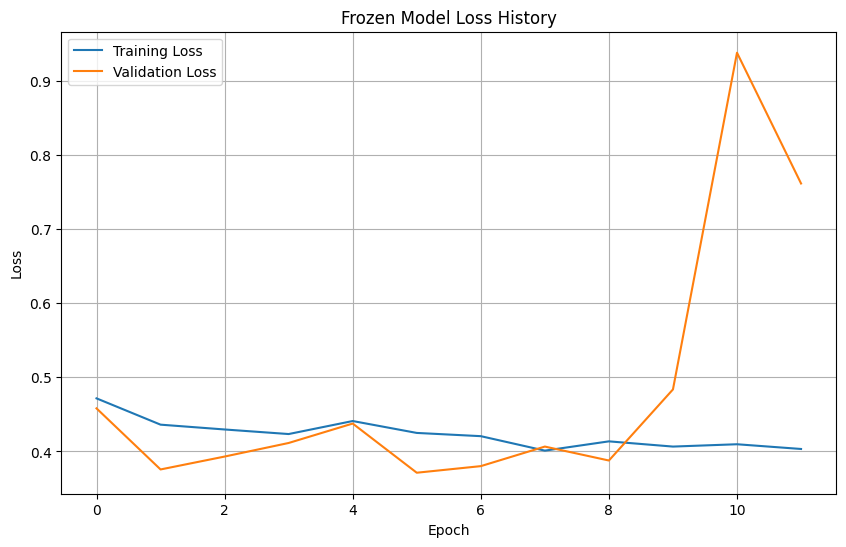

In [ ]:
plot_loss_history(train_loss_history_frozen,val_loss_history_frozen,'Frozen Model',"Frozen_Model_Loss")

Plot saved to Unfrozen_Model_Loss


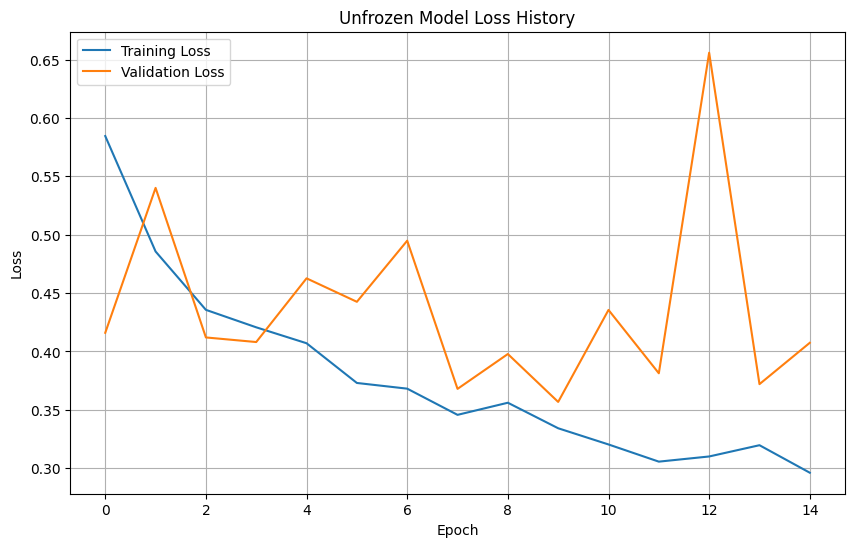

In [ ]:
plot_loss_history(train_loss_history_unfrozen,val_loss_history_unfrozen,'Unfrozen Model',"Unfrozen_Model_Loss")

Plot saved to AUC_Comparison


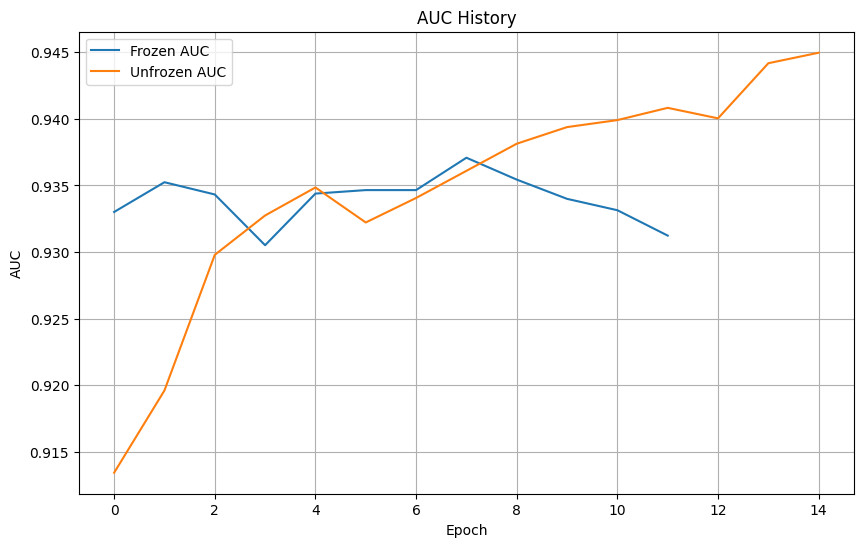

In [ ]:
plot_auc_history(auc_history_frozen,auc_history_unfrozen, "AUC_Comparison")

Test Loss: 0.6282190680503845, AUC: 0.8917946219444275
Accuracy: 0.8167202472686768, Precision: 0.8095238208770752, Recall: 0.6967213153839111, F1 Score: 0.7488986849784851
Confusion matrix saved to Frozen Model_confusion_matrix


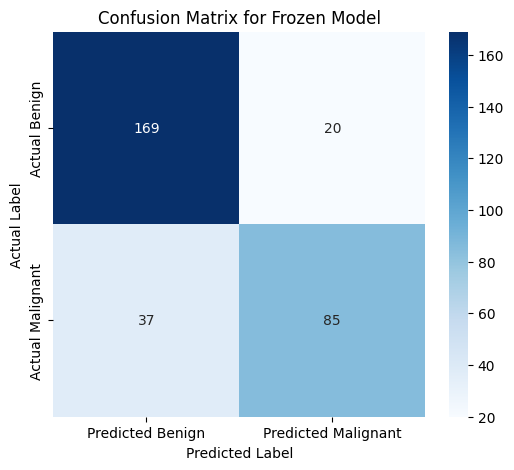

In [ ]:
frozen_test_loss, roc_auc = test(model_frozen,"Frozen Model",test_loader,device)


Test Loss: 0.46594589948654175, AUC: 0.9407581090927124
Accuracy: 0.881028950214386, Precision: 0.8571428656578064, Recall: 0.8360655903816223, F1 Score: 0.8464730381965637
Confusion matrix saved to Unfrozen Model_confusion_matrix


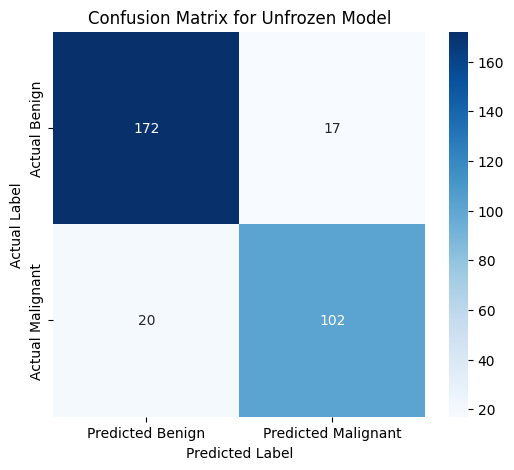

In [ ]:
unfrozen_test_loss, roc_auc = test(model_unfrozen,"Unfrozen Model",test_loader,device)